## Only Core 전략 

### 1. 데이터 준비

In [13]:
# --- 1. 데이터 준비 ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy.optimize import minimize

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩
tickers = ['SHYG', 'IEF', 'AGGY'] # 전략 자산 + 벤치마크
start_date = '2015-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'

# 데이터 통합 및 전처리
df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
daily_returns = df[['SHYG', 'IEF', 'AGGY']].pct_change().dropna()

print("데이터 준비 완료.")

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/1961971732.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed



데이터 준비 완료.


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/1961971732.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


In [3]:
df

,AGGY,IEF,SHYG,OAS
2015-07-09,36.032482,84.855743,27.154783,5.11
2015-07-10,35.808655,84.267860,27.227812,4.97
2015-07-13,35.808655,84.042404,27.255920,4.93
2015-07-14,35.808655,84.308205,27.250305,4.94
2015-07-15,35.808655,84.630234,27.227812,4.93
...,...,...,...,...
2025-09-19,44.380001,96.629997,43.310001,2.72
2025-09-22,44.305000,96.470001,43.369999,2.69
2025-09-23,44.389999,96.739998,43.340000,2.71
2025-09-24,44.270000,96.480003,43.299999,2.70


### 2.전략적 포지셔닝

In [14]:
# --- 2. Neutral 포트폴리오 최적화 ---

# 각 ETF의 평균 듀레이션 가정
DURATIONS = {'SHYG': 2.1, 'IEF': 7.03}

def optimize_neutral_portfolio(returns):
    num_assets = returns.shape[1]
    
    def objective(weights):
        portfolio_return = np.sum(returns.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
        return -portfolio_return / portfolio_vol # Negative Sharpe Ratio

    def duration_constraint(weights):
        portfolio_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * weights)
        return portfolio_duration

    cons = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}, # Weights sum to 1
        {'type': 'ineq', 'fun': lambda x: duration_constraint(x) - 3}, # Duration >= 3
        {'type': 'ineq', 'fun': lambda x: 5 - duration_constraint(x)}  # Duration <= 5
    )
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array(num_assets * [1. / num_assets])
    
    result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=cons)
    
    return result.x

# 최적화 실행
neutral_weights = optimize_neutral_portfolio(daily_returns[['SHYG', 'IEF']])
neutral_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * neutral_weights)

print("--- Neutral 포트폴리오 최적화 결과 ---")
print(f"SHYG 최적 비중: {neutral_weights[0]:.2%}")
print(f"IEF 최적 비중: {neutral_weights[1]:.2%}")
print(f"결과 포트폴리오 듀레이션: {neutral_duration:.2f}년")

--- Neutral 포트폴리오 최적화 결과 ---
SHYG 최적 비중: 80.50%
IEF 최적 비중: 19.50%
결과 포트폴리오 듀레이션: 3.06년


### 3단계: 레짐 타이밍 (월별 신호 생성)

In [15]:
# --- 3. 월별 신호 생성 ---
df_monthly = df.resample('M').last() # 월별 데이터로 리샘플링

# ELP Proxy 신호 생성
def price_to_elp(price): # Exhibit 4 테이블 매핑 함수
    if price < 30: return 0.70;
    elif price < 35: return 0.65;
    elif price < 95: return 0.25 - (price - 70) // 5 * 0.05
    elif price < 100: return 0.025;
    elif price < 105: return 0.0125;
    else: return max(0.0015625, 0.0125 / (2**((price-105)//5)))

df_monthly['ELP'] = df_monthly['SHYG'].apply(price_to_elp)
df_monthly['ELP_Z'] = (df_monthly['ELP'] - df_monthly['ELP'].mean()) / df_monthly['ELP'].std()

# OAS 모멘텀 신호 생성 (3개월 지수이동평균 사용)
df_monthly['OAS_EWMA3'] = df_monthly['OAS'].ewm(span=3).mean()
df_monthly['OAS_Momentum_Up'] = df_monthly['OAS'] > df_monthly['OAS_EWMA3']

# 레짐 결정 및 목표 비중 설정
def get_target_weights(row):
    if row['ELP_Z'] < -1: return [0.8, 0.2]  # Very Risk-on
    elif row['ELP_Z'] > 1: return [0.5, 0.5]  # Very Risk-off
    elif row['OAS_Momentum_Up']: return [0.6, 0.4]  # Risk-off
    else: return neutral_weights.tolist() # Risk-on (Neutral)

# 시차(Lookahead bias) 방지를 위해 shift(1) 적용
df_monthly['Target_Weights'] = [w for w in df_monthly.apply(get_target_weights, axis=1).shift(1)]

print("\n월별 레짐 및 목표 비중 생성 완료.")


월별 레짐 및 목표 비중 생성 완료.


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/1489038870.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M').last() # 월별 데이터로 리샘플링


### 4단계: 월별 리밸런싱 백테스팅 (거래 비용 포함)

In [10]:
# --- 4. 백테스팅 실행 (수정된 코드) ---
transaction_cost = 0.001 # 0.10% (10bp)

# 초기 설정
initial_capital = 1.0
capital = initial_capital
# [수정] current_weights를 neutral_weights로 초기화하여 첫 거래 비용을 정확히 계산
current_weights = np.array(neutral_weights) 
portfolio_values = []
dates = []

# 일별 데이터를 월별로 그룹화하여 순회
for month, month_df in daily_returns.groupby(pd.Grouper(freq='M')):
    target_weights = df_monthly.loc[month, 'Target_Weights']

    # ----------------- [수정된 부분 START] -----------------
    # target_weights가 정상적인 리스트 형태가 아닌 경우(NaN 등) 건너뜁니다.
    if not isinstance(target_weights, list):
    # ----------------- [수정된 부분 END] -------------------
        # 첫 달은 신호가 없으므로 자본 변동 없이 날짜만 기록
        for date in month_df.index:
            portfolio_values.append(capital)
            dates.append(date)
        continue

    # 거래 비용 계산
    target_weights_arr = np.array(target_weights) # 비교를 위해 array로 변환
    trade_cost = np.sum(np.abs(current_weights - target_weights_arr)) * transaction_cost
    capital *= (1 - trade_cost)
    current_weights = target_weights_arr

    # 해당 월의 포트폴리오 수익률 계산
    for date, row in month_df.iterrows():
        daily_return = np.sum(row[['SHYG', 'IEF']] * current_weights)
        capital *= (1 + daily_return)
        portfolio_values.append(capital)
        dates.append(date)

# 최종 결과 데이터프레임 생성
strategy_df = pd.DataFrame({'Strategy': portfolio_values}, index=pd.to_datetime(dates))

# [수정] 벤치마크와 join하기 전에 인덱스 중복 제거
strategy_df = strategy_df[~strategy_df.index.duplicated(keep='first')]

benchmark_df = (1 + daily_returns['AGGY']).cumprod()
final_df = strategy_df.join(benchmark_df.rename('Benchmark'), how='inner')

print("백테스팅 완료.")

백테스팅 완료.


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/3485176702.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  for month, month_df in daily_returns.groupby(pd.Grouper(freq='M')):


### 5단계 : 성과분석 및 시각화


--- 성과 지표 비교 ---
           CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)
Strategy       3.61            4.83          0.75   -12.16
Benchmark      2.05            5.44          0.38   -20.97


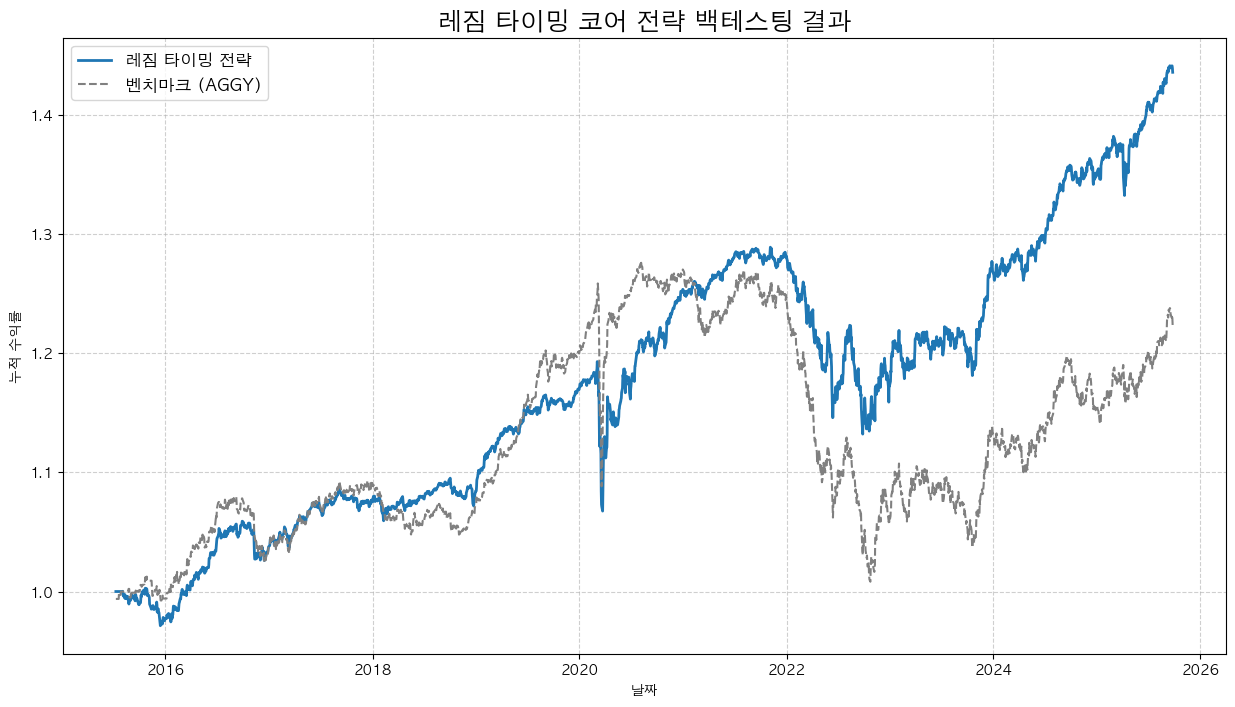

In [11]:
# --- 5. 성과 분석 ---
def calculate_performance_metrics(returns_series):
    days = len(returns_series)
    trading_days_per_year = 252
    cagr = (returns_series.iloc[-1] / returns_series.iloc[0]) ** (trading_days_per_year / days) - 1
    annualized_vol = returns_series.pct_change().std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = cagr / annualized_vol
    cumulative = returns_series
    peak = cumulative.expanding(min_periods=1).max()
    drawdown = (cumulative - peak) / peak
    mdd = drawdown.min()
    return {'CAGR (%)': cagr*100, 'Volatility (%)': annualized_vol*100, 'Sharpe Ratio': sharpe_ratio, 'MDD (%)': mdd*100}

# 성과 지표 출력
strategy_returns = final_df['Strategy']
benchmark_returns = final_df['Benchmark']
metrics = pd.DataFrame({
    'Strategy': calculate_performance_metrics(strategy_returns),
    'Benchmark': calculate_performance_metrics(benchmark_returns)
}).T
print("\n--- 성과 지표 비교 ---")
print(metrics.round(2))

# 누적 수익률 시각화
plt.figure(figsize=(15, 8))
plt.plot(final_df.index, final_df['Strategy'], label='레짐 타이밍 전략', linewidth=2)
plt.plot(final_df.index, final_df['Benchmark'], label='벤치마크 (AGGY)', linestyle='--', color='gray')
plt.title('레짐 타이밍 코어 전략 백테스팅 결과', fontsize=18)
plt.xlabel('날짜')
plt.ylabel('누적 수익률')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 시각화 고도화

In [17]:
# --- 3. 월별 신호 생성 (오류 수정) ---
df_monthly = df.resample('ME').last() # 월별 데이터로 리샘플링 ('M' -> 'ME'로 변경)

# ELP Proxy 신호 생성
def price_to_elp(price): # Exhibit 4 테이블 매핑 함수
    if price < 30: return 0.70;
    elif price < 35: return 0.65;
    elif price < 95: return 0.25 - (price - 70) // 5 * 0.05
    elif price < 100: return 0.025;
    elif price < 105: return 0.0125;
    else: return max(0.0015625, 0.0125 / (2**((price-105)//5)))

df_monthly['ELP'] = df_monthly['SHYG'].apply(price_to_elp)
df_monthly['ELP_Z'] = (df_monthly['ELP'] - df_monthly['ELP'].mean()) / df_monthly['ELP'].std()

# OAS 모멘텀 신호 생성 (3개월 지수이동평균 사용)
df_monthly['OAS_EWMA3'] = df_monthly['OAS'].ewm(span=3).mean()
df_monthly['OAS_Momentum_Up'] = df_monthly['OAS'] > df_monthly['OAS_EWMA3']

# 레짐 맵핑 정보
regime_map = {'Very Risk-on': 1, 'Risk-on': 2, 'Risk-off': 3, 'Very Risk-off': 4}
regime_colors = {1: 'darkgreen', 2: 'skyblue', 3: 'orange', 4: 'red'}
regime_labels = {
    1: '1: Very Risk-on (듀레이션↓, SHYG 80%)',
    2: '2: Risk-on (기본 유지)', # 기본 비중은 최적화 결과에 따라 달라짐
    3: '3: Risk-off (OAS↑, 듀레이션↑, SHYG 60%)',
    4: '4: Very Risk-off (ELP↑, 듀레이션↑↑, SHYG 50%)'
}

# Risk-on 레짐의 라벨을 최적화된 비중으로 업데이트
regime_labels[2] = f"2: Risk-on (기본 유지, SHYG {neutral_weights[0]:.0%})"


def get_regime_and_target_weights(row):
    if row['ELP_Z'] < -1: return ([0.8, 0.2], regime_map['Very Risk-on'])
    elif row['ELP_Z'] > 1: return ([0.5, 0.5], regime_map['Very Risk-off'])
    elif row['OAS_Momentum_Up']: return ([0.6, 0.4], regime_map['Risk-off'])
    else: return (neutral_weights.tolist(), regime_map['Risk-on'])

# 시차(Lookahead bias) 방지를 위해 shift(1) 적용
temp_results = df_monthly.apply(get_regime_and_target_weights, axis=1).shift(1)

# ----------------- [수정된 부분 START] -----------------
# temp_results의 각 항목(x)이 유효한 값일 때만(NaN이 아닐 때만) 인덱싱하도록 수정
df_monthly['Target_Weights'] = [x[0] if pd.notna(x) else None for x in temp_results]
df_monthly['Regime'] = [x[1] if pd.notna(x) else None for x in temp_results]
# ----------------- [수정된 부분 END] -------------------


print("\n월별 레짐 및 목표 비중 생성 완료.")


월별 레짐 및 목표 비중 생성 완료.


In [21]:
# --- 4. 백테스팅 실행 (회전율 계산 추가) ---
transaction_cost = 0.001 # 0.10% (10bp)

# 초기 설정
initial_capital = 1.0
capital = initial_capital
current_weights = np.array(neutral_weights)
portfolio_values = []
dates = []
monthly_turnovers = [] # 월별 회전율을 저장할 리스트

# 일별 데이터를 월별로 그룹화하여 순회
for month, month_df in daily_returns.groupby(pd.Grouper(freq='ME')):
    target_weights = df_monthly.loc[month, 'Target_Weights']

    if not isinstance(target_weights, list):
        for date in month_df.index:
            portfolio_values.append(capital)
            dates.append(date)
        continue

    target_weights_arr = np.array(target_weights)

    # --- [추가] 회전율 계산 ---
    # 지난달 비중(current_weights)과 이번달 목표 비중(target_weights_arr)의 차이를 계산
    turnover = np.sum(np.abs(current_weights - target_weights_arr)) / 2
    monthly_turnovers.append(turnover)
    # --------------------------

    # 거래 비용 계산
    trade_cost = turnover * 2 * transaction_cost # 회전율을 이미 계산했으므로 이를 활용
    capital *= (1 - trade_cost)
    current_weights = target_weights_arr

    # 해당 월의 포트폴리오 수익률 계산
    for date, row in month_df.iterrows():
        daily_return = np.sum(row[['SHYG', 'IEF']] * current_weights)
        capital *= (1 + daily_return)
        portfolio_values.append(capital)
        dates.append(date)

# 최종 결과 데이터프레임 생성
strategy_df = pd.DataFrame({'Strategy': portfolio_values}, index=pd.to_datetime(dates))
strategy_df = strategy_df[~strategy_df.index.duplicated(keep='first')]
benchmark_df = (1 + daily_returns['AGGY']).cumprod()
final_df = strategy_df.join(benchmark_df.rename('Benchmark'), how='inner')

# --- [추가] 최종 회전율 계산 및 출력 ---
average_monthly_turnover = np.mean(monthly_turnovers)
annualized_turnover = average_monthly_turnover * 12

print("백테스팅 완료.\n")
print("--- 포트폴리오 회전율 분석 ---")
print(f"월평균 회전율: {average_monthly_turnover:.2%}")
print(f"연간 회전율: {annualized_turnover:.2%}")

백테스팅 완료.

--- 포트폴리오 회전율 분석 ---
월평균 회전율: 6.54%
연간 회전율: 78.53%



--- 성과 지표 비교 ---
           CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)
Strategy       3.61            4.83          0.75   -12.16
Benchmark      2.05            5.44          0.38   -20.97


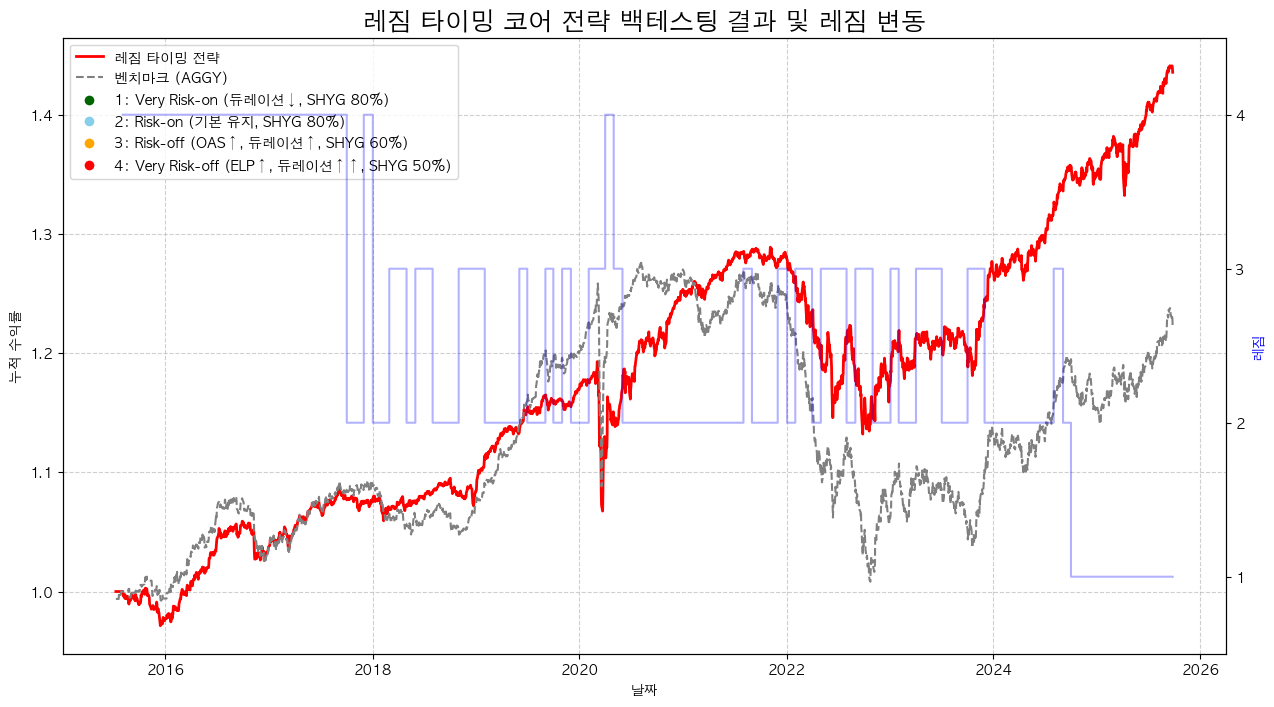

In [19]:
# --- 5. 성과 분석 (시각화에 레짐 표시 추가) ---
def calculate_performance_metrics(returns_series):
    days = len(returns_series)
    trading_days_per_year = 252
    cagr = (returns_series.iloc[-1] / returns_series.iloc[0]) ** (trading_days_per_year / days) - 1
    annualized_vol = returns_series.pct_change().std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = cagr / annualized_vol
    cumulative = returns_series
    peak = cumulative.expanding(min_periods=1).max()
    drawdown = (cumulative - peak) / peak
    mdd = drawdown.min()
    return {'CAGR (%)': cagr*100, 'Volatility (%)': annualized_vol*100, 'Sharpe Ratio': sharpe_ratio, 'MDD (%)': mdd*100}

# 성과 지표 출력
strategy_returns = final_df['Strategy']
benchmark_returns = final_df['Benchmark']
metrics = pd.DataFrame({
    'Strategy': calculate_performance_metrics(strategy_returns),
    'Benchmark': calculate_performance_metrics(benchmark_returns)
}).T
print("\n--- 성과 지표 비교 ---")
print(metrics.round(2))

# 누적 수익률 시각화 (레짐 표시 추가)
fig, ax1 = plt.subplots(figsize=(15, 8))

ax1.plot(final_df.index, final_df['Strategy'], label='레짐 타이밍 전략', linewidth=2, color='red')
ax1.plot(final_df.index, final_df['Benchmark'], label='벤치마크 (AGGY)', linestyle='--', color='gray')
ax1.set_xlabel('날짜')
ax1.set_ylabel('누적 수익률')
ax1.set_title('레짐 타이밍 코어 전략 백테스팅 결과 및 레짐 변동', fontsize=18)
ax1.grid(True, linestyle='--', alpha=0.6)

# 레짐을 위한 보조 y축 설정
ax2 = ax1.twinx()
ax2.set_ylabel('레짐', color='blue')

# 레짐 그래프 (스텝 플롯으로 레짐 변화 명확히)
# 레짐 값이 NaN이 아닌 경우만 플롯
valid_regimes = final_df['Regime'].dropna()
ax2.step(valid_regimes.index, valid_regimes.values, where='post', color='blue', alpha=0.3, label='레짐 변동')
ax2.set_ylim(0.5, 4.5) # 레짐 번호에 맞춰 y축 범위 조정
ax2.set_yticks(list(regime_labels.keys())) # 레짐 번호만 y틱으로 표시
ax2.set_yticklabels(list(regime_labels.keys())) # 레짐 번호 텍스트 표시


# 범례 통합 (첫 번째 축에 모든 범례를 모아서 표시)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# 레짐별 라벨과 색상으로 범례 추가
regime_patches = []
for r_id in sorted(regime_labels.keys()):
    if r_id in valid_regimes.unique(): # 실제 데이터에 존재하는 레짐만 범례에 추가
        patch = plt.Line2D([0], [0], marker='o', color='w', label=regime_labels[r_id],
                           markerfacecolor=regime_colors[r_id], markersize=8)
        regime_patches.append(patch)

ax1.legend(handles=handles1 + regime_patches, loc='upper left', fontsize=10) # 레짐 범례 추가

plt.show()

In [20]:
metrics

,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%)
Strategy,3.610373,4.834979,0.746720,-12.164611
Benchmark,2.054904,5.438382,0.377852,-20.970261


## 코어전략 : TLT 추가 

In [23]:
# --- 1. 데이터 준비 (TLT 추가) ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy.optimize import minimize

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# [수정] Tickers에 TLT 추가
tickers = ['SHYG', 'IEF', 'AGGY', 'TLT']
start_date = '2015-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'

# 데이터 통합 및 전처리
df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
daily_returns = df[['SHYG', 'IEF', 'AGGY', 'TLT']].pct_change().dropna()

print("데이터 준비 완료.")

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/1805558259.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed



데이터 준비 완료.


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/1805558259.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


In [24]:
# --- 2. Neutral 포트폴리오 최적화 ---
DURATIONS = {'SHYG': 2.1, 'IEF': 7.6}
def optimize_neutral_portfolio(returns):
    num_assets = returns.shape[1]
    def objective(weights):
        portfolio_return = np.sum(returns.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
        return -portfolio_return / portfolio_vol
    def duration_constraint(weights):
        portfolio_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * weights)
        return portfolio_duration
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},{'type': 'ineq', 'fun': lambda x: duration_constraint(x) - 3},{'type': 'ineq', 'fun': lambda x: 5 - duration_constraint(x)})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array(num_assets * [1. / num_assets])
    result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=cons)
    return result.x

neutral_weights = optimize_neutral_portfolio(daily_returns[['SHYG', 'IEF']])
print(f"Neutral 비중 (SHYG/IEF): {neutral_weights[0]:.1%}, {neutral_weights[1]:.1%}")

Neutral 비중 (SHYG/IEF): 80.5%, 19.5%


In [25]:
# --- 3. 수정된 레짐 타이밍 신호 생성 ---
df_monthly = df.resample('ME').last()
# ELP Proxy 신호
def price_to_elp(price):
    if price < 95: return 0.25 - (price - 70) // 5 * 0.05
    elif price < 100: return 0.025
    else: return max(0.0015625, 0.0125 / (2**((price-100)//5)))
df_monthly['ELP'] = df_monthly['SHYG'].apply(price_to_elp)
df_monthly['ELP_Z'] = (df_monthly['ELP'] - df_monthly['ELP'].mean()) / df_monthly['ELP'].std()
# OAS 모멘텀 신호
df_monthly['OAS_EWMA3'] = df_monthly['OAS'].ewm(span=3).mean()
df_monthly['OAS_Momentum_Up'] = df_monthly['OAS'] > df_monthly['OAS_EWMA3']

# [수정] 레짐별 목표 비중 함수 (SHYG, IEF, TLT 순)
def get_target_weights_with_tlt(row):
    if row['ELP_Z'] < -1: return [0.8, 0.2, 0.0]        # Very Risk-on
    elif row['ELP_Z'] > 1: return [0.5, 0.0, 0.5]        # Very Risk-off (IEF -> TLT)
    elif row['OAS_Momentum_Up']: return [0.6, 0.4, 0.0]  # Risk-off
    else: return [neutral_weights[0], neutral_weights[1], 0.0] # Risk-on (Neutral)

# 시차 적용하여 최종 목표 비중 생성
df_monthly['Target_Weights'] = [w for w in df_monthly.apply(get_target_weights_with_tlt, axis=1).shift(1)]

print("\n수정된 월별 레짐 및 목표 비중 생성 완료.")


수정된 월별 레짐 및 목표 비중 생성 완료.


In [30]:
# --- 4. 백테스팅 실행 (3개 자산 기준 + 회전율 계산) ---
transaction_cost = 0.001
initial_capital = 1.0
capital = initial_capital
# [수정] 초기 비중을 3개 자산에 맞게 설정
current_weights = np.array([neutral_weights[0], neutral_weights[1], 0.0])
portfolio_values = []
dates = []
monthly_turnovers = [] # 월별 회전율을 저장할 리스트

for month, month_df in daily_returns.groupby(pd.Grouper(freq='ME')):
    target_weights = df_monthly.loc[month, 'Target_Weights']

    if not isinstance(target_weights, list):
        for date in month_df.index:
            portfolio_values.append(capital)
            dates.append(date)
        continue

    target_weights_arr = np.array(target_weights)

    # --- [추가] 회전율 계산 ---
    turnover = np.sum(np.abs(current_weights - target_weights_arr)) / 2
    monthly_turnovers.append(turnover)
    # --------------------------

    trade_cost = turnover * 2 * transaction_cost
    capital *= (1 - trade_cost)
    current_weights = target_weights_arr

    # 3개 자산의 일일 수익률 계산
    for date, row in month_df.iterrows():
        daily_return = np.sum(row[['SHYG', 'IEF', 'TLT']] * current_weights)
        capital *= (1 + daily_return)
        portfolio_values.append(capital)
        dates.append(date)

# 최종 결과 데이터프레임 생성
strategy_df = pd.DataFrame({'Strategy_TLT': portfolio_values}, index=pd.to_datetime(dates))
strategy_df = strategy_df[~strategy_df.index.duplicated(keep='first')]
strategy_df['Strategy_Original'] = final_df['Strategy']
benchmark_df = (1 + daily_returns['AGGY']).cumprod()
final_df_comparison = strategy_df.join(benchmark_df.rename('Benchmark'), how='inner')

# --- [추가] 최종 회전율 계산 및 출력 ---
average_monthly_turnover = np.mean(monthly_turnovers)
annualized_turnover = average_monthly_turnover * 12

print("백테스팅 완료.\n")
print("--- '최대 방어 전략' 포트폴리오 회전율 분석 ---")
print(f"월평균 회전율: {average_monthly_turnover:.2%}")
print(f"연간 회전율: {annualized_turnover:.2%}")

백테스팅 완료.

--- '최대 방어 전략' 포트폴리오 회전율 분석 ---
월평균 회전율: 7.84%
연간 회전율: 94.12%



--- 최종 성과 지표 비교 ---
                CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
기존 전략               3.61            4.83          0.75   -12.16          0.30
최대 방어 전략 (TLT)      3.91            5.41          0.72   -12.16          0.32
벤치마크                2.05            5.44          0.38   -20.97          0.10


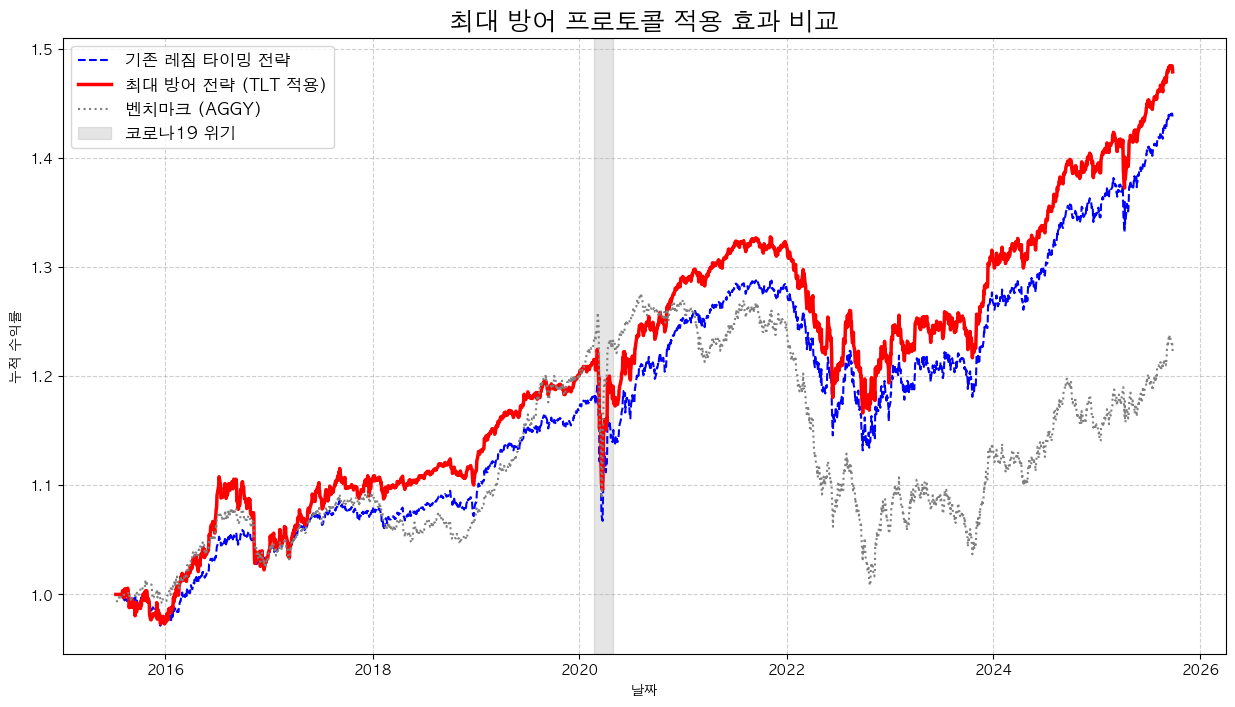

In [28]:
# --- 5. 성과 비교 분석 ---
# 성과 지표 계산 함수 (재사용)
def calculate_performance_metrics(returns_series):
    days = len(returns_series); trading_days_per_year = 252
    cagr = (returns_series.iloc[-1] / returns_series.iloc[0]) ** (trading_days_per_year / days) - 1
    annualized_vol = returns_series.pct_change().std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = cagr / annualized_vol
    mdd = (returns_series / returns_series.expanding(min_periods=1).max() - 1).min()
    calmar_ratio = cagr / abs(mdd)
    return {'CAGR (%)': cagr*100, 'Volatility (%)': annualized_vol*100, 'Sharpe Ratio': sharpe_ratio, 'MDD (%)': mdd*100, 'Calmar Ratio': calmar_ratio}

# 성과 지표 출력
metrics_comparison = pd.DataFrame({
    '기존 전략': calculate_performance_metrics(final_df_comparison['Strategy_Original']),
    '최대 방어 전략 (TLT)': calculate_performance_metrics(final_df_comparison['Strategy_TLT']),
    '벤치마크': calculate_performance_metrics(final_df_comparison['Benchmark'])
}).T
print("\n--- 최종 성과 지표 비교 ---")
print(metrics_comparison.round(2))

# 누적 수익률 시각화
plt.figure(figsize=(15, 8))
plt.plot(final_df_comparison.index, final_df_comparison['Strategy_Original'], label='기존 레짐 타이밍 전략', linestyle='--', color='blue')
plt.plot(final_df_comparison.index, final_df_comparison['Strategy_TLT'], label='최대 방어 전략 (TLT 적용)', linewidth=2.5, color='red')
plt.plot(final_df_comparison.index, final_df_comparison['Benchmark'], label='벤치마크 (AGGY)', linestyle=':', color='gray')
plt.axvspan('2020-02-20', '2020-04-30', color='gray', alpha=0.2, label='코로나19 위기')
plt.title('최대 방어 프로토콜 적용 효과 비교', fontsize=18)
plt.xlabel('날짜'); plt.ylabel('누적 수익률')
plt.legend(fontsize=12); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [29]:
metrics_comparison

,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
기존 전략,3.610373,4.834979,0.746720,-12.164611,0.296793
최대 방어 전략 (TLT),3.914579,5.410338,0.723537,-12.164513,0.321803
벤치마크,2.054904,5.438382,0.377852,-20.970261,0.097991


## 코어전략 + 위성전략

In [41]:
# --- 1. 데이터 준비 (위성 전략 지표 추가) ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy.optimize import minimize

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# [수정] Tickers에 SHY 추가 (위성 전략 현금성 자산)
tickers = ['SHYG', 'IEF', 'AGGY', 'TLT', 'SHY']
start_date = '2015-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
# [수정] 위성 전략을 위한 10년물 금리(DGS10) 추가
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'
dgs10_data = fred.get_series('DGS10', start_date=start_date, end_date=end_date)
dgs10_data.name = 'DGS10'

# 데이터 통합 및 전처리
df = etf_data.join(oas_data, how='inner').join(dgs10_data, how='inner')
df.fillna(method='ffill', inplace=True)
df.dropna(inplace=True)
daily_returns = df[['SHYG', 'IEF', 'AGGY', 'TLT', 'SHY']].pct_change().dropna()

print("데이터 준비 완료.")

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/2052868633.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed



데이터 준비 완료.


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/2052868633.py:35: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [42]:
# --- 2. 코어 & 위성 전략 신호 생성 ---

# --- 2.1 코어 전략 신호 (월별) ---
df_monthly = df.resample('ME').last()
# ELP Proxy 신호
def price_to_elp(price):
    if price < 95: return 0.25 - (price - 70) // 5 * 0.05
    elif price < 100: return 0.025
    else: return max(0.0015625, 0.0125 / (2**((price-100)//5)))
df_monthly['ELP'] = df_monthly['SHYG'].apply(price_to_elp)
df_monthly['ELP_Z'] = (df_monthly['ELP'] - df_monthly['ELP'].mean()) / df_monthly['ELP'].std()
# OAS 모멘텀 신호
df_monthly['OAS_EWMA3'] = df_monthly['OAS'].ewm(span=3).mean()
df_monthly['OAS_Momentum_Up'] = df_monthly['OAS'] > df_monthly['OAS']
# Neutral 비중 최적화 (재사용)
neutral_weights = [0.697, 0.303]
# 코어 전략 레짐별 목표 비중 (SHYG, IEF, TLT)
def get_core_target_weights(row):
    if row['ELP_Z'] < -1: return [0.8, 0.2, 0.0]
    elif row['ELP_Z'] > 1: return [0.5, 0.0, 0.5]
    elif row['OAS_Momentum_Up']: return [0.6, 0.4, 0.0]
    else: return [neutral_weights[0], neutral_weights[1], 0.0]
df_monthly['Core_Target_Weights'] = [w for w in df_monthly.apply(get_core_target_weights, axis=1).shift(1)]


# --- 2.2 위성 전략 신호 (일별) ---
entry_threshold = 4.2
exit_threshold = 4.0
satellite_active = False
satellite_signals = []

for rate in df['DGS10']:
    if not satellite_active and rate >= entry_threshold:
        satellite_active = True
    elif satellite_active and rate <= exit_threshold:
        satellite_active = False
    satellite_signals.append(satellite_active)

df['Satellite_Active'] = pd.Series(satellite_signals, index=df.index).shift(1)
df['Satellite_Active'].fillna(False, inplace=True)


print("\n코어(월별) 및 위성(일별) 신호 생성 완료.")


코어(월별) 및 위성(일별) 신호 생성 완료.


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/1542451108.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Satellite_Active'].fillna(False, inplace=True)
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_5574/1542451108.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['S

In [51]:
# --- 3. 코어-위성 및 코어 단독 전략 백테스팅 (수정된 코드) ---

# --- 3.1 코어-위성 전략 백테스팅 ---
core_alloc = 0.85
satellite_alloc = 0.15
transaction_cost = 0.001

# 초기 설정
capital_cs = 1.0
core_weights_cs = np.array([neutral_weights[0], neutral_weights[1], 0.0])
is_satellite_in_ief = False
portfolio_values_cs = []
dates_cs = []
turnovers_cs = []

# 월별/일별 루프 (코어-위성)
for month_start, month_df in df.groupby(pd.Grouper(freq='MS')):
    previous_month_end = month_start - pd.DateOffset(days=1)
    if previous_month_end in df_monthly.index:
        core_target_weights = df_monthly.loc[previous_month_end, 'Core_Target_Weights']
    else:
        core_target_weights = None

    if isinstance(core_target_weights, list):
        core_target_weights_arr = np.array(core_target_weights)
        core_turnover = np.sum(np.abs(core_weights_cs - core_target_weights_arr)) / 2
        core_trade_cost = core_turnover * 2 * transaction_cost
        capital_cs *= (1 - core_trade_cost * core_alloc)
        core_weights_cs = core_target_weights_arr
        turnovers_cs.append(core_turnover * core_alloc)

    for date, row in month_df.iterrows():
        if date not in daily_returns.index:
            portfolio_values_cs.append(capital_cs); dates_cs.append(date); continue
        
        satellite_target_active = row['Satellite_Active']
        satellite_trade_cost = 0.0
        if satellite_target_active != is_satellite_in_ief:
            is_satellite_in_ief = satellite_target_active
            satellite_trade_cost = satellite_alloc * transaction_cost
            turnovers_cs.append(satellite_alloc)
        
        capital_cs *= (1 - satellite_trade_cost)
        core_return = np.sum(daily_returns.loc[date, ['SHYG', 'IEF', 'TLT']] * core_weights_cs)
        satellite_asset = 'IEF' if is_satellite_in_ief else 'SHY'
        satellite_return = daily_returns.loc[date, satellite_asset]
        total_daily_return = core_return * core_alloc + satellite_return * satellite_alloc
        capital_cs *= (1 + total_daily_return)
        portfolio_values_cs.append(capital_cs); dates_cs.append(date)

# 코어-위성 결과 DF
core_satellite_df = pd.DataFrame({'Core_Satellite': portfolio_values_cs}, index=pd.to_datetime(dates_cs))
annualized_turnover = np.sum(turnovers_cs) / (len(df)/252)
print("--- '코어-위성 전략' 포트폴리오 회전율 분석 ---")
print(f"연간 회전율: {annualized_turnover:.2%}")


# --- 3.2 코어 단독 전략 백테스팅 (재계산) ---
capital_co = 1.0
core_weights_co = np.array([neutral_weights[0], neutral_weights[1], 0.0])
portfolio_values_co = []
dates_co = []

for month_start, month_df in df.groupby(pd.Grouper(freq='MS')):
    previous_month_end = month_start - pd.DateOffset(days=1)
    if previous_month_end in df_monthly.index:
        core_target_weights = df_monthly.loc[previous_month_end, 'Core_Target_Weights']
    else:
        core_target_weights = None

    if isinstance(core_target_weights, list):
        core_target_weights_arr = np.array(core_target_weights)
        core_trade_cost = np.sum(np.abs(core_weights_co - core_target_weights_arr)) * transaction_cost
        capital_co *= (1 - core_trade_cost)
        core_weights_co = core_target_weights_arr

    for date, row in month_df.iterrows():
        if date not in daily_returns.index:
            portfolio_values_co.append(capital_co); dates_co.append(date); continue
        
        daily_return = np.sum(daily_returns.loc[date, ['SHYG', 'IEF', 'TLT']] * core_weights_co)
        capital_co *= (1 + daily_return)
        portfolio_values_co.append(capital_co); dates_co.append(date)

core_only_df = pd.DataFrame({'Core_Only': portfolio_values_co}, index=pd.to_datetime(dates_co))


# --- 3.3 최종 데이터프레임 병합 ---
benchmark_df = (1 + daily_returns['AGGY']).cumprod().rename('Benchmark')
final_comparison_df = core_satellite_df.join(core_only_df, how='inner').join(benchmark_df, how='inner')
final_comparison_df = final_comparison_df.join(df['Satellite_Active'], how='inner')


# --- 4. 최종 성과 비교 및 시각화 (기존과 동일) ---
# (이전과 동일한 4단계 코드를 여기에 붙여넣으시면 됩니다)
# ... (이하 동일)

--- '코어-위성 전략' 포트폴리오 회전율 분석 ---
연간 회전율: 42.06%



--- 최종 성과 지표 비교 ---
          CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
코어-위성 전략      3.35            4.99          0.67   -10.66          0.31
코어 단독 전략      3.51            5.61          0.62   -12.44          0.28
벤치마크          2.10            5.44          0.39   -20.97          0.10


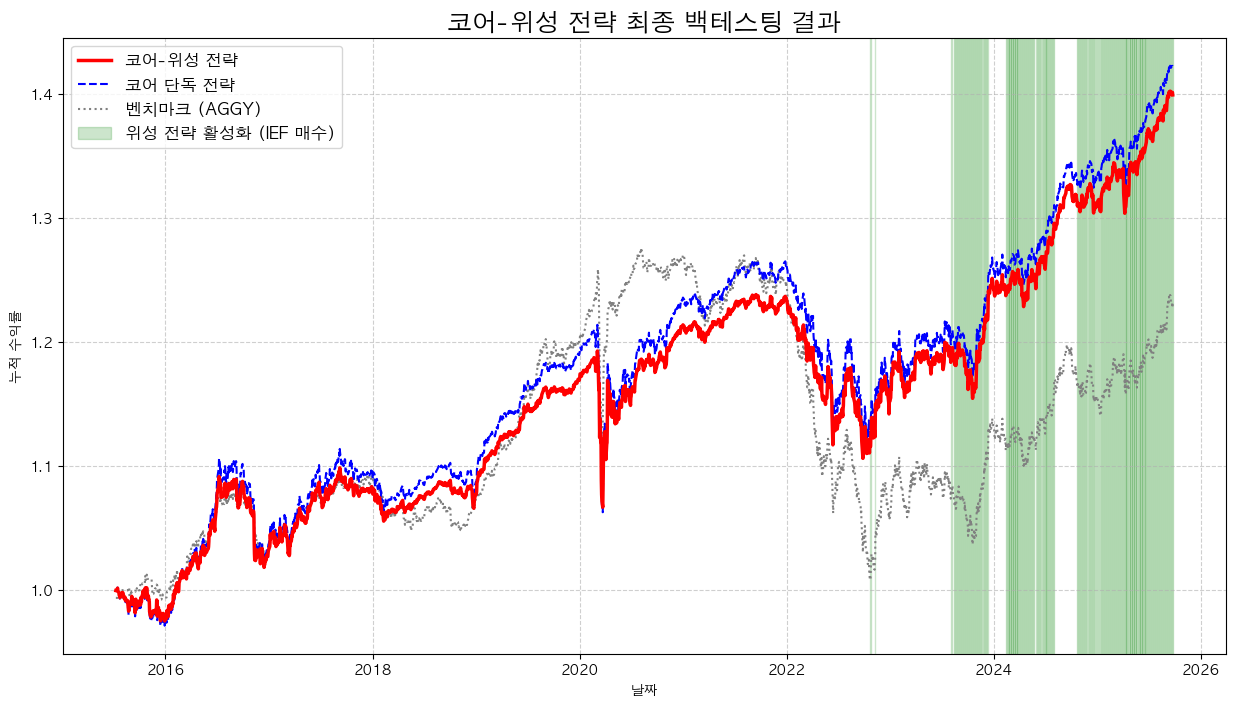

In [52]:
# --- 4. 최종 성과 비교 및 시각화 (오류 수정) ---

# 성과 지표 계산 함수 (재사용)
def calculate_performance_metrics(returns_series):
    days = len(returns_series); trading_days_per_year = 252
    cagr = (returns_series.iloc[-1] / returns_series.iloc[0]) ** (trading_days_per_year / days) - 1
    annualized_vol = returns_series.pct_change().std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = cagr / annualized_vol
    mdd = (returns_series / returns_series.expanding(min_periods=1).max() - 1).min()
    calmar_ratio = cagr / abs(mdd)
    return {'CAGR (%)': cagr*100, 'Volatility (%)': annualized_vol*100, 'Sharpe Ratio': sharpe_ratio, 'MDD (%)': mdd*100, 'Calmar Ratio': calmar_ratio}

# 성과 지표 출력
metrics = pd.DataFrame({
    '코어-위성 전략': calculate_performance_metrics(final_comparison_df['Core_Satellite']),
    '코어 단독 전략': calculate_performance_metrics(final_comparison_df['Core_Only']),
    '벤치마크': calculate_performance_metrics(final_comparison_df['Benchmark'])
}).T
print("\n--- 최종 성과 지표 비교 ---")
print(metrics.round(2))


# 시각화
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(final_comparison_df.index, final_comparison_df['Core_Satellite'], label='코어-위성 전략', linewidth=2.5, color='red', zorder=5)
ax.plot(final_comparison_df.index, final_comparison_df['Core_Only'], label='코어 단독 전략', linestyle='--', color='blue', zorder=4)
ax.plot(final_comparison_df.index, final_comparison_df['Benchmark'], label='벤치마크 (AGGY)', linestyle=':', color='gray', zorder=3)


# --- [수정된 부분 START] ---
# 위성 전략 활성화 구간 음영 처리
satellite_active_dates = final_comparison_df[final_comparison_df['Satellite_Active']]
legend_added = False # 범례 중복 방지를 위한 플래그

# groupby가 반환하는 값은 (그룹 키, 그룹 데이터프레임) 입니다.
for _, group_df in satellite_active_dates.groupby((satellite_active_dates.index.to_series().diff().dt.days > 1).cumsum()):
    label_text = '위성 전략 활성화 (IEF 매수)' if not legend_added else ""
    ax.axvspan(group_df.index[0], group_df.index[-1], color='green', alpha=0.2, label=label_text)
    legend_added = True # 첫 번째 음영 처리 후 플래그를 True로 변경
# --- [수정된 부분 END] ---


ax.set_title('코어-위성 전략 최종 백테스팅 결과', fontsize=18)
ax.set_xlabel('날짜'); ax.set_ylabel('누적 수익률')
ax.legend(fontsize=12); ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

###  벤치마크 AGG로 변경

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_1736/3514577658.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_1736/3514577658.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()


--- 1. 데이터 준비 완료 ---
--- 2. Neutral 비중 계산 완료 (SHYG/IEF): 81.8%, 18.2%
--- 3. 월별 레짐 신호 생성 완료 ---
--- 4. 백테스팅 완료 (연간 회전율: 94.42%) ---

--- 5. 최종 성과 지표 비교 ---
            CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
최대 방어 전략        3.28            5.58          0.59   -11.94          0.27
벤치마크 (AGG)      1.75            5.29          0.33   -18.43          0.10


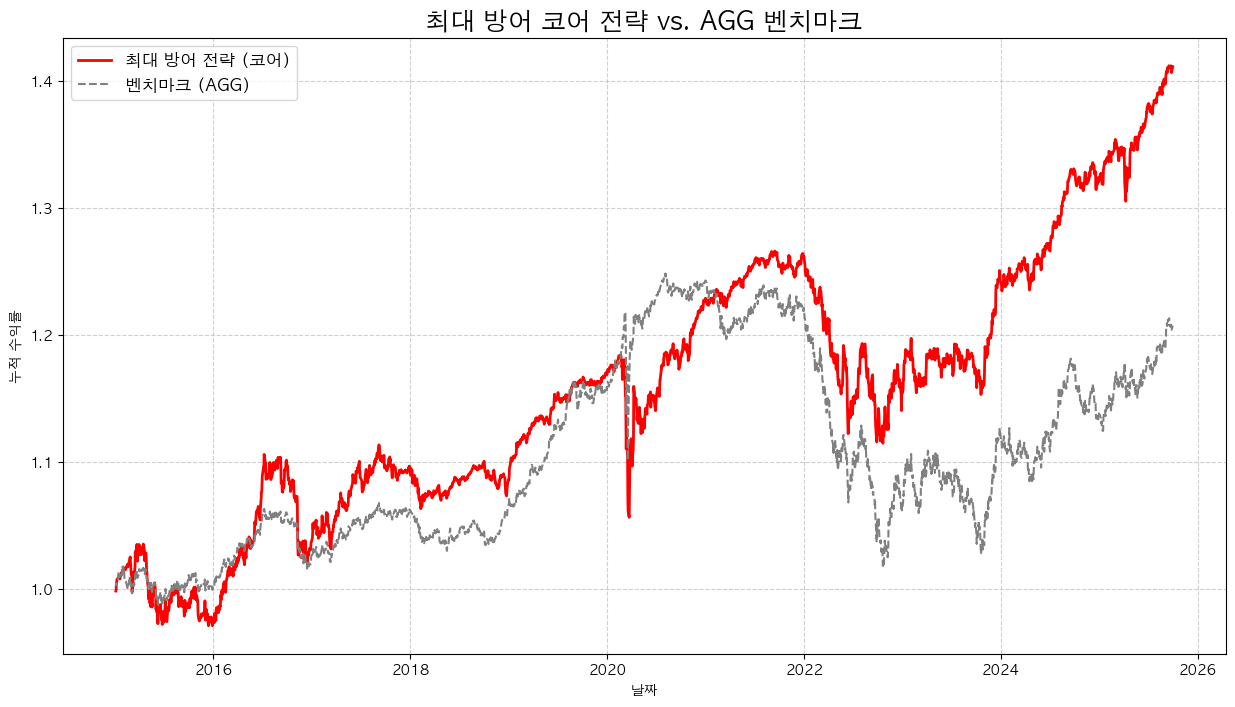

In [1]:
# --- 1단계: 데이터 준비 (벤치마크 변경: AGG) ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy.optimize import minimize

# 한글 폰트 설정
try:
    import platform
    if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
    else: plt.rc('font', family='NanumGothic')
except ImportError: pass
plt.rcParams['axes.unicode_minus'] = False

# [수정] 벤치마크를 AGG로 변경 (AGGY -> AGG)
tickers = ['SHYG', 'IEF', 'TLT', 'AGG']
start_date = '2015-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)
oas_data = fred.get_series('BAMLH0A0HYM2', start_date=start_date, end_date=end_date)
oas_data.name = 'OAS'

# 데이터 통합 및 전처리
df = etf_data.join(oas_data, how='inner').fillna(method='ffill').dropna()
daily_returns = df.pct_change().dropna()

print("--- 1. 데이터 준비 완료 ---")


# --- 2단계: Neutral 포트폴리오 최적화 (기존과 동일) ---
DURATIONS = {'SHYG': 2.1, 'IEF': 7.6}
def optimize_neutral_portfolio(returns):
    num_assets = returns.shape[1]
    def objective(weights):
        portfolio_return = np.sum(returns.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
        return -portfolio_return / portfolio_vol
    def duration_constraint(weights):
        portfolio_duration = np.sum(np.array([DURATIONS['SHYG'], DURATIONS['IEF']]) * weights)
        return portfolio_duration
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},{'type': 'ineq', 'fun': lambda x: duration_constraint(x) - 3},{'type': 'ineq', 'fun': lambda x: 5 - duration_constraint(x)})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array(num_assets * [1. / num_assets])
    result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=cons)
    return result.x

neutral_weights = optimize_neutral_portfolio(daily_returns[['SHYG', 'IEF']])
print(f"--- 2. Neutral 비중 계산 완료 (SHYG/IEF): {neutral_weights[0]:.1%}, {neutral_weights[1]:.1%}")


# --- 3단계: 레짐 타이밍 신호 생성 (TLT 규칙 적용) ---
df_monthly = df.resample('ME').last()
def price_to_elp(price):
    if price < 95: return 0.25 - (price - 70) // 5 * 0.05
    elif price < 100: return 0.025
    else: return max(0.0015625, 0.0125 / (2**((price-100)//5)))
df_monthly['ELP'] = df_monthly['SHYG'].apply(price_to_elp)
df_monthly['ELP_Z'] = (df_monthly['ELP'] - df_monthly['ELP'].mean()) / df_monthly['ELP'].std()
df_monthly['OAS_EWMA3'] = df_monthly['OAS'].ewm(span=3).mean()
df_monthly['OAS_Momentum_Up'] = df_monthly['OAS'] > df_monthly['OAS_EWMA3']
def get_target_weights_with_tlt(row):
    if row['ELP_Z'] < -1: return [0.8, 0.2, 0.0]
    elif row['ELP_Z'] > 1: return [0.5, 0.0, 0.5]
    elif row['OAS_Momentum_Up']: return [0.6, 0.4, 0.0]
    else: return [neutral_weights[0], neutral_weights[1], 0.0]
df_monthly['Target_Weights'] = [w for w in df_monthly.apply(get_target_weights_with_tlt, axis=1).shift(1)]
print("--- 3. 월별 레짐 신호 생성 완료 ---")


# --- 4단계: 월별 리밸런싱 백테스팅 ---
transaction_cost = 0.001
initial_capital = 1.0
capital = initial_capital
current_weights = np.array([neutral_weights[0], neutral_weights[1], 0.0])
portfolio_values = []
dates = []
monthly_turnovers = []

for month_start, month_df in df.groupby(pd.Grouper(freq='MS')):
    previous_month_end = month_start - pd.DateOffset(days=1)
    if previous_month_end in df_monthly.index:
        target_weights = df_monthly.loc[previous_month_end, 'Target_Weights']
    else:
        target_weights = None

    if isinstance(target_weights, list):
        target_weights_arr = np.array(target_weights)
        turnover = np.sum(np.abs(current_weights - target_weights_arr)) / 2
        monthly_turnovers.append(turnover)
        trade_cost = turnover * 2 * transaction_cost
        capital *= (1 - trade_cost)
        current_weights = target_weights_arr

    for date, row in month_df.iterrows():
        if date not in daily_returns.index: continue
        daily_return = np.sum(daily_returns.loc[date, ['SHYG', 'IEF', 'TLT']] * current_weights)
        capital *= (1 + daily_return)
        portfolio_values.append(capital)
        dates.append(date)

strategy_df = pd.DataFrame({'Strategy': portfolio_values}, index=pd.to_datetime(dates))
strategy_df = strategy_df[~strategy_df.index.duplicated(keep='first')]
benchmark_df = (1 + daily_returns['AGG']).cumprod()
final_df = strategy_df.join(benchmark_df.rename('Benchmark'), how='inner')
annualized_turnover = np.mean(monthly_turnovers) * 12
print(f"--- 4. 백테스팅 완료 (연간 회전율: {annualized_turnover:.2%}) ---")


# --- 5단계: 성과 분석 및 시각화 ---
def calculate_performance_metrics(returns_series):
    days = len(returns_series); trading_days_per_year = 252
    cagr = (returns_series.iloc[-1] / returns_series.iloc[0]) ** (trading_days_per_year / days) - 1
    annualized_vol = returns_series.pct_change().std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = cagr / annualized_vol
    mdd = (returns_series / returns_series.expanding(min_periods=1).max() - 1).min()
    calmar_ratio = cagr / abs(mdd)
    return {'CAGR (%)': cagr*100, 'Volatility (%)': annualized_vol*100, 'Sharpe Ratio': sharpe_ratio, 'MDD (%)': mdd*100, 'Calmar Ratio': calmar_ratio}

metrics = pd.DataFrame({
    '최대 방어 전략': calculate_performance_metrics(final_df['Strategy']),
    '벤치마크 (AGG)': calculate_performance_metrics(final_df['Benchmark'])
}).T
print("\n--- 5. 최종 성과 지표 비교 ---")
print(metrics.round(2))

plt.figure(figsize=(15, 8))
plt.plot(final_df.index, final_df['Strategy'], label='최대 방어 전략 (코어)', linewidth=2, color='red')
plt.plot(final_df.index, final_df['Benchmark'], label='벤치마크 (AGG)', linestyle='--', color='gray')
plt.title('최대 방어 코어 전략 vs. AGG 벤치마크', fontsize=18)
plt.xlabel('날짜'); plt.ylabel('누적 수익률')
plt.legend(fontsize=12); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()